# Sistema de Navegación Asistida por Visión Artificial — Versión Optimizada
## Clasificación Multilabel de Elementos del Entorno — Piso 2, Edificio Cornelio Merchán (UPS, Sede Cuenca)

**Asignatura:** Inteligencia Artificial y Aprendizaje Automático
**Práctica:** Redes Neuronales — Problemas Multilabel
**Autores:** Sebastien Reinoso y Doménica Beltrán

---

### Planteamiento del problema

El sistema apoya la movilidad de personas con discapacidad visual reconociendo, a partir de una fotografía, **qué elementos de navegación están presentes en el entorno inmediato** (señalética en pared, puertas, escaleras, obstáculos, pasillos). Una misma imagen puede contener varios de estos elementos simultáneamente (por ejemplo, una puerta y un pasillo en la misma toma), por lo que el problema es genuinamente **multilabel**: no se predice una única clase excluyente, sino el subconjunto de etiquetas presentes en la imagen.

> **Alcance de esta entrega (prueba de concepto, 2 días de implementación):** el dataset se acotó al **segundo piso** del edificio Cornelio Merchán, combinando fotografías propias del piso (para `letrero_pared`, `puerta`, `pasillo`) con imágenes de repositorios públicos de internet (para `escalera` y `obstaculo`, elementos genéricos no específicos del edificio). El volumen se limitó a 150–200 imágenes para evitar sobreajuste y agilizar el etiquetado manual. Extender la recolección a otros pisos queda como trabajo futuro, mencionado en las conclusiones.

A partir del conjunto de etiquetas que predice la red, se genera un mensaje descriptivo del entorno (formato texto estructurado, pensado para ser consumido por un lector de pantalla):

```
Imagen -> [Red Neuronal Multilabel] -> {puerta, pasillo}
                                              |
                                  (generación de mensaje)
                                              v
                       "Elementos detectados: puerta, pasillo."
```

**Esquema de etiquetas (`LABEL_VOCAB`):**

| Etiqueta | Descripción | Origen de las imágenes |
|---|---|---|
| `letrero_pared` | Letrero o rótulo fijado en pared | Fotografía propia (piso 2) |
| `puerta` | Puerta de oficina, laboratorio o aula | Fotografía propia (piso 2) |
| `pasillo` | Pasillo o corredor | Fotografía propia (piso 2) |
| `escalera` | Escaleras | Repositorio público de internet |
| `obstaculo` | Obstáculo común en el paso (silla, caja, etc.) | Repositorio público de internet |

> Importante para el reporte (criterio de "Descripción del Dataset" de la rúbrica): documenten la fuente exacta (URL/repositorio) de cada imagen descargada de internet, y cítenla en formato APA en la sección de referencias.

---

### Optimizaciones aplicadas respecto a la versión original

1. **`decode_image`** en vez de `decode_jpeg` → soporta JPEG y PNG sin errores
2. **Split estratificado multilabel** con `iterative_train_test_split` (scikit-multilearn)
3. **Data augmentation mejorada** como capas de Keras (rotación, zoom, traslación, brillo, contraste)
4. **Cabeza clasificadora mejorada** con BatchNormalization, L2 regularization, y capa densa adicional
5. **Label smoothing** (0.1) para reducir sobreajuste
6. **Warm-up del learning rate** en las primeras 3 épocas
7. **Evaluación ampliada** con matrices de confusión, curvas ROC, y búsqueda de threshold óptimo por etiqueta
8. **Exportación corregida** a ONNX (SavedModel → ONNX)
9. **Validación de integridad** del dataset antes de entrenar

## 0. Configuración del entorno

Instala las dependencias (solo la primera vez). Como entrenarán en Jupyter local con GPU propia, asegúrense de tener instalado el driver de CUDA/cuDNN compatible con la versión de TensorFlow que usen.

In [2]:
# Ejecutar una sola vez. Descomenta si te falta alguna librería.
# %pip install tensorflow scikit-learn matplotlib seaborn pandas pillow opencv-python tf2onnx scikit-multilearn-ng scipy

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detectadas:", gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1784043772.237624    8930 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784043772.477566    8930 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784043774.135322    8930 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Descripción del problema y del dataset

**Organización esperada de carpetas:**

```
data/
├── images/              # todas las fotos (jpg/png), nombres únicos
└── labels.csv           # filename, labels  (labels separadas por ";")
```

Ejemplo de `labels.csv` (dataset híbrido: fotos propias del piso 2 + imágenes de internet):

```
filename,labels,fuente
IMG_0001.jpg,letrero_pared;pasillo,propia
IMG_0002.jpg,puerta;pasillo,propia
web_0003.jpg,escalera,internet
web_0004.jpg,obstaculo,internet
```

In [19]:
DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "images"
LABELS_CSV = DATA_DIR / "labels.csv"

# Vocabulario de etiquetas del proyecto: elementos de navegación en el entorno (piso 2)
LABEL_VOCAB = [
    "letrero_pared",
    "puerta",
    "escalera",
    "obstaculo",
    "pasillo",
]

if LABELS_CSV.exists():
    df = pd.read_csv(LABELS_CSV)
    df["labels_list"] = df["labels"].apply(lambda s: s.split(";"))
    df["filepath"] = df["filename"].apply(lambda f: str(IMAGES_DIR / f))

    # ── OPTIMIZACIÓN: Validación de integridad del dataset ──────────────
    # Verificar que cada archivo listado en el CSV realmente existe en disco
    existe = df["filepath"].apply(os.path.exists)
    archivos_faltantes = df[~existe]
    if len(archivos_faltantes) > 0:
        print(f"⚠️  {len(archivos_faltantes)} archivos del CSV no encontrados en disco:")
        for f in archivos_faltantes["filename"].tolist():
            print(f"     - {f}")
        df = df[existe].reset_index(drop=True)
        print(f"   Se descartaron automáticamente. Dataset resultante: {len(df)} imágenes.\n")

    # Verificar etiquetas desconocidas (que no estén en LABEL_VOCAB)
    todas_etiquetas = set(e for lista in df["labels_list"] for e in lista)
    desconocidas = todas_etiquetas - set(LABEL_VOCAB)
    if desconocidas:
        print(f"⚠️  Etiquetas no reconocidas en el CSV: {desconocidas}")
        print("   Revisa el etiquetado — estas etiquetas serán ignoradas en el multi-hot.\n")

    # Estadísticas del dataset
    print(f"✅ Dataset cargado: {len(df)} imágenes")
    print(f"   Etiquetas en vocabulario: {len(LABEL_VOCAB)}")
    print(f"   Etiquetas por imagen (promedio): {df['labels_list'].apply(len).mean():.2f}")
    if "fuente" in df.columns:
        print(f"\n   Distribución por fuente:")
        for fuente, count in df["fuente"].value_counts().items():
            print(f"     {fuente}: {count}")
    display(df.head())
else:
    print(f"Aún no existe {LABELS_CSV}. Crea la carpeta data/images con las fotos "
          f"y un labels.csv como el del ejemplo de arriba antes de continuar.")
    df = pd.DataFrame(columns=["filename", "labels", "labels_list", "filepath"])

✅ Dataset cargado: 224 imágenes
   Etiquetas en vocabulario: 5
   Etiquetas por imagen (promedio): 2.38

   Distribución por fuente:
     propia: 171
     internet: 53


,filename,labels,fuente,labels_list,filepath
0,IMG_1017.JPG,letrero_pared;puerta,propia,"[letrero_pared, puerta]",data/images/IMG_1017.JPG
1,IMG_1018.JPG,letrero_pared;puerta,propia,"[letrero_pared, puerta]",data/images/IMG_1018.JPG
2,IMG_1019.JPG,letrero_pared;puerta,propia,"[letrero_pared, puerta]",data/images/IMG_1019.JPG
3,IMG_1020.JPG,letrero_pared;puerta,propia,"[letrero_pared, puerta]",data/images/IMG_1020.JPG
4,IMG_1021.JPG,letrero_pared;puerta,propia,"[letrero_pared, puerta]",data/images/IMG_1021.JPG


## 2. Análisis exploratorio de imágenes (EDA)

Función para visualizar imágenes con sus etiquetas, gráfico de frecuencia de etiquetas,
y **matriz de co-ocurrencia** (nueva) para entender qué etiquetas aparecen juntas.

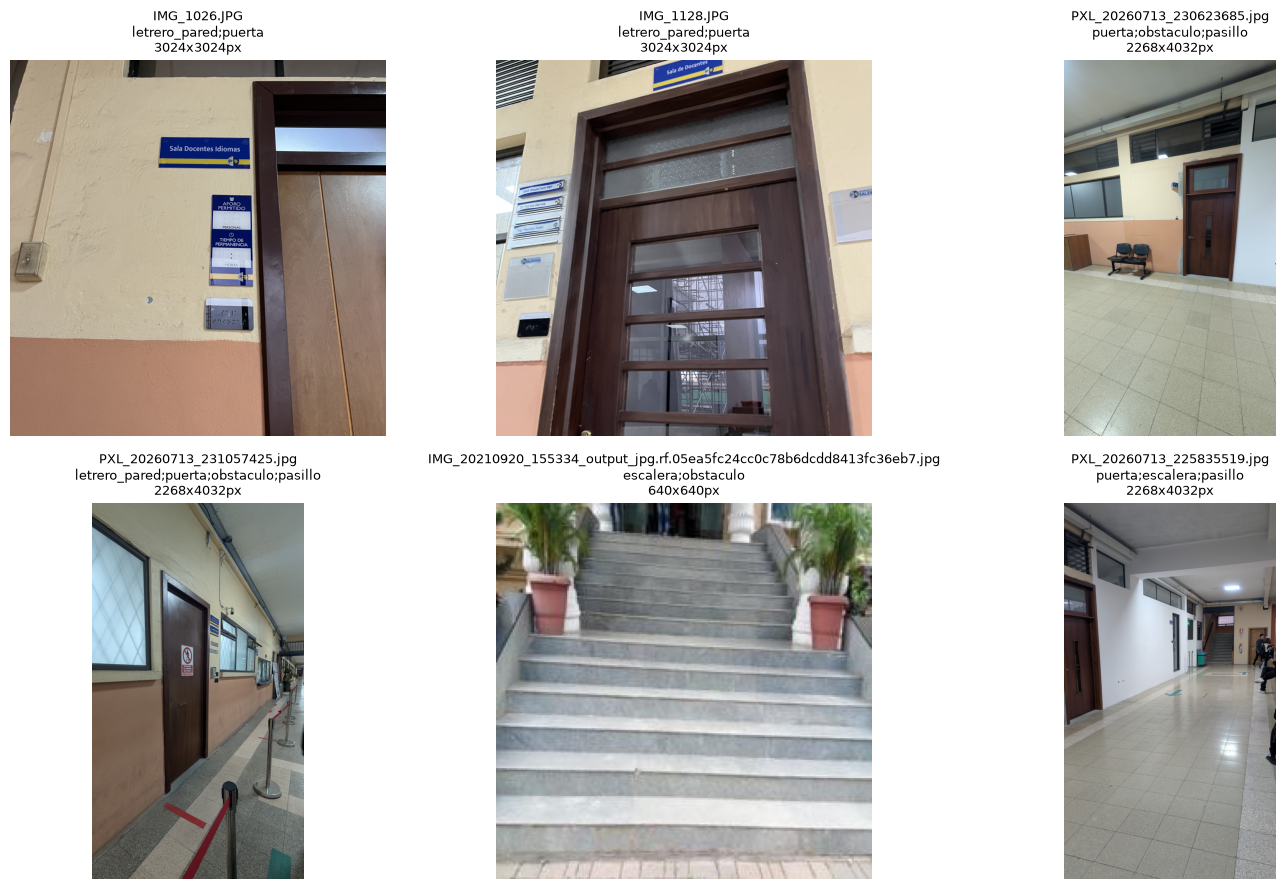

In [20]:
def mostrar_imagenes(dataframe, n=6, cols=3, seed=SEED):
    """Muestra n imágenes aleatorias del dataframe junto con sus etiquetas y dimensiones."""
    muestra = dataframe.sample(min(n, len(dataframe)), random_state=seed)
    rows = int(np.ceil(len(muestra) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, muestra.iterrows()):
        img = tf.keras.utils.load_img(row["filepath"])
        w, h = img.size
        ax.imshow(img)
        ax.set_title(f"{row['filename']}\n{row['labels']}\n{w}x{h}px", fontsize=9)
        ax.axis("off")

    for ax in axes[len(muestra):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if len(df):
    mostrar_imagenes(df, n=6)

/tmp/ipykernel_8930/2975032458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=serie.values, y=serie.index, palette=colores)


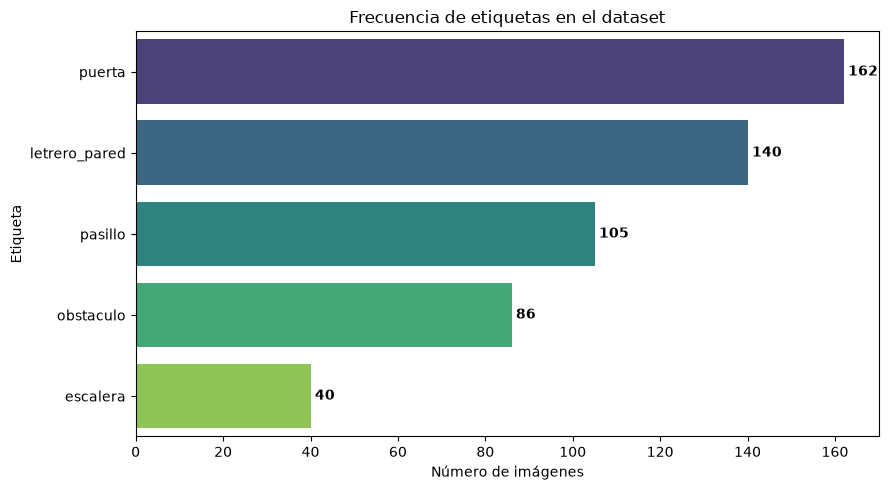

puerta           162
letrero_pared    140
pasillo          105
obstaculo         86
escalera          40
dtype: int64

Etiquetas por imagen (promedio): 2.38


In [6]:
def graficar_frecuencia_etiquetas(dataframe, vocab):
    """Grafica la frecuencia de cada etiqueta en el dataset con valores anotados."""
    conteo = {etiqueta: 0 for etiqueta in vocab}
    for labels_list in dataframe["labels_list"]:
        for etiqueta in labels_list:
            if etiqueta in conteo:
                conteo[etiqueta] += 1

    serie = pd.Series(conteo).sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    colores = sns.color_palette("viridis", len(serie))
    sns.barplot(x=serie.values, y=serie.index, palette=colores)
    plt.xlabel("Número de imágenes")
    plt.ylabel("Etiqueta")
    plt.title("Frecuencia de etiquetas en el dataset")
    for i, v in enumerate(serie.values):
        plt.text(v + 1, i, str(v), va="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return serie

if len(df):
    frecuencias = graficar_frecuencia_etiquetas(df, LABEL_VOCAB)
    print(frecuencias)
    print("\nEtiquetas por imagen (promedio):", df["labels_list"].apply(len).mean().round(2))

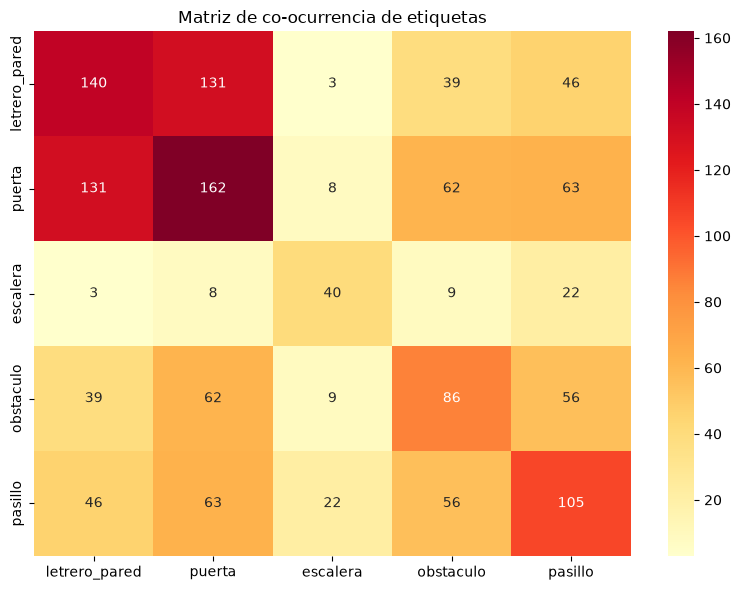

In [7]:
# ── OPTIMIZACIÓN: Matriz de co-ocurrencia de etiquetas ──────────────
def graficar_coocurrencia(dataframe, vocab):
    """Matriz de co-ocurrencia: muestra qué etiquetas aparecen juntas frecuentemente.
    La diagonal muestra la frecuencia individual de cada etiqueta."""
    n = len(vocab)
    cooc = np.zeros((n, n), dtype=int)
    for labels_list in dataframe["labels_list"]:
        indices = [vocab.index(e) for e in labels_list if e in vocab]
        for i in indices:
            for j in indices:
                cooc[i][j] += 1

    plt.figure(figsize=(8, 6))
    sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd",
                xticklabels=vocab, yticklabels=vocab)
    plt.title("Matriz de co-ocurrencia de etiquetas")
    plt.tight_layout()
    plt.show()

if len(df):
    graficar_coocurrencia(df, LABEL_VOCAB)

## 3. Preprocesamiento y pipeline de datos (tf.data)

Convertimos las etiquetas a formato *multi-hot* y construimos un pipeline `tf.data`.

**Optimizaciones aplicadas:**
- **`tf.io.decode_image`** en vez de `decode_jpeg` para soportar JPEG y PNG
- **Split estratificado multilabel** con `iterative_train_test_split` de scikit-multilearn
- **Augmentation** movida a capas de Keras en el modelo (se desactivan automáticamente en inferencia)
- El pipeline de datos ahora devuelve imágenes en `[0, 255]` — el modelo se encarga del preprocesamiento

In [21]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8   # dataset pequeño (150-200 img); con más datos puedes subir a 16/32
NUM_CLASSES = len(LABEL_VOCAB)

mlb_index = {etiqueta: i for i, etiqueta in enumerate(LABEL_VOCAB)}

def etiquetas_a_multihot(labels_list):
    """Convierte una lista de etiquetas a un vector multi-hot."""
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for etiqueta in labels_list:
        if etiqueta in mlb_index:
            vec[mlb_index[etiqueta]] = 1.0
    return vec


# ── OPTIMIZACIÓN: Split estratificado para multilabel ──────────────
def construir_datasets(dataframe, test_size=0.15, val_size=0.15, seed=SEED):
    """Split estratificado que mantiene la distribución de etiquetas en train/val/test.

    Usa IterativeStratification con 3 folds directamente (en vez de dos splits
    secuenciales) para evitar inconsistencias de dimensiones en scikit-multilearn.
    Si falla, usa sklearn train_test_split como fallback."""
    from sklearn.model_selection import train_test_split

    y_matrix = np.stack(dataframe["labels_list"].apply(etiquetas_a_multihot).values)

    try:
        from skmultilearn.model_selection import IterativeStratification

        X = np.arange(len(dataframe)).reshape(-1, 1)
        y_sparse = sp.csr_matrix(y_matrix)
        train_size = 1.0 - test_size - val_size

        # Un solo stratifier con 3 folds: [test, val, train]
        stratifier = IterativeStratification(
            n_splits=3,
            order=2,
            sample_distribution_per_fold=[test_size, val_size, train_size],
            random_state=seed,
        )

        # Cada iteración de split() devuelve (otros_idx, fold_idx)
        # fold_idx contiene los índices asignados a ese fold
        fold_indices = [fold_idx for _, fold_idx in stratifier.split(X, y_sparse)]

        test_df  = dataframe.iloc[fold_indices[0]].reset_index(drop=True)
        val_df   = dataframe.iloc[fold_indices[1]].reset_index(drop=True)
        train_df = dataframe.iloc[fold_indices[2]].reset_index(drop=True)

        print("✅ Split estratificado multilabel (IterativeStratification, 3 folds)")

    except Exception as e:
        print(f"⚠️  IterativeStratification falló: {e}")
        print("   Usando fallback con sklearn train_test_split...")

        # Fallback robusto: estratificar por combinación de etiquetas cuando sea posible
        strat_key = dataframe["labels"].values
        try:
            train_val_df, test_df = train_test_split(
                dataframe, test_size=test_size, random_state=seed, stratify=strat_key
            )
            adjusted_val = val_size / (1 - test_size)
            strat_key_2 = train_val_df["labels"].values
            train_df, val_df = train_test_split(
                train_val_df, test_size=adjusted_val, random_state=seed, stratify=strat_key_2
            )
        except ValueError:
            # Si alguna combinación tiene muy pocos ejemplos, split sin estratificar
            train_val_df, test_df = train_test_split(
                dataframe, test_size=test_size, random_state=seed
            )
            adjusted_val = val_size / (1 - test_size)
            train_df, val_df = train_test_split(
                train_val_df, test_size=adjusted_val, random_state=seed
            )

        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("\nDistribución de etiquetas por split:")
    for nombre, subset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        conteo = {e: 0 for e in LABEL_VOCAB}
        for ll in subset["labels_list"]:
            for e in ll:
                if e in conteo:
                    conteo[e] += 1
        resumen = "  ".join(f"{k}={v}" for k, v in conteo.items())
        print(f"  {nombre:>5s}: {resumen}")

    return train_df, val_df, test_df


# ── OPTIMIZACIÓN: decode_image en vez de decode_jpeg (soporta PNG) ──────────────
def cargar_imagen(path, label):
    """Carga y redimensiona una imagen. Soporta JPEG, PNG y otros formatos.
    Devuelve pixeles en [0, 255] — el modelo hace el preprocesamiento internamente."""
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return img, label


def dataframe_a_tfdataset(dataframe, training=False):
    """Crea un tf.data.Dataset desde un DataFrame.
    El parámetro training solo controla el shuffle (la augmentation se maneja en el modelo)."""
    paths = dataframe["filepath"].values
    labels = np.stack(dataframe["labels_list"].apply(etiquetas_a_multihot).values)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(cargar_imagen, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


if len(df):
    train_df, val_df, test_df = construir_datasets(df)
    train_ds = dataframe_a_tfdataset(train_df, training=True)
    val_ds = dataframe_a_tfdataset(val_df, training=False)
    test_ds = dataframe_a_tfdataset(test_df, training=False)

⚠️  IterativeStratification falló: tuple index out of range
   Usando fallback con sklearn train_test_split...
Train: 156 | Val: 34 | Test: 34

Distribución de etiquetas por split:
  Train: letrero_pared=99  puerta=112  escalera=26  obstaculo=57  pasillo=73
    Val: letrero_pared=20  puerta=27  escalera=7  obstaculo=15  pasillo=18
   Test: letrero_pared=21  puerta=23  escalera=7  obstaculo=14  pasillo=14


## 4. Diseño del modelo (transfer learning multilabel)

Usamos **MobileNetV2** preentrenada en ImageNet como extractor de características, con una cabeza densa multilabel mejorada:

- **Data augmentation como capas de Keras** (RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomBrightness, RandomContrast): se activan solo durante `model.fit()` y se desactivan automáticamente en `model.predict()`
- **Rescaling integrado** en el modelo: convierte `[0, 255]` → `[-1, 1]` (preprocesamiento de MobileNetV2)
- **BatchNormalization** después de GlobalAveragePooling2D para estabilizar el entrenamiento
- **Regularización L2** en las capas densas para reducir sobreajuste
- **Label smoothing** (0.1) en la loss para mejorar generalización con dataset pequeño
- Última capa con `NUM_CLASSES` neuronas y activación **sigmoid** (no softmax: las clases no son mutuamente excluyentes)
- Pérdida **binary_crossentropy** (se evalúa cada etiqueta como un problema binario independiente)

In [22]:
# ── OPTIMIZACIÓN: Data augmentation como capas de Keras ──────────────
# Las capas RandomX se activan solo durante training y son no-ops en inferencia
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),                  # ±10% de rotación
    layers.RandomZoom((-0.1, 0.1)),              # ±10% de zoom
    layers.RandomTranslation(0.05, 0.05),        # ±5% de traslación
    layers.RandomBrightness(0.2),                # ±20% de brillo
    layers.RandomContrast(0.2),                  # ±20% de contraste
], name="data_augmentation")


# ── OPTIMIZACIÓN: Cabeza mejorada con BatchNorm, L2, y capa densa adicional ──────
def construir_modelo(num_classes, img_size=IMG_SIZE, fine_tune_at=None):
    """Construye el modelo con MobileNetV2 como backbone.

    Args:
        num_classes: número de etiquetas de salida
        img_size: tupla (alto, ancho) de la imagen de entrada
        fine_tune_at: índice de la capa a partir de la cual descongelar el backbone.
                      Si None, el backbone se congela completamente (Fase 1).
    """
    base_model = applications.MobileNetV2(
        input_shape=img_size + (3,),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = fine_tune_at is not None

    if fine_tune_at is not None:
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=img_size + (3,))

    # Augmentation (solo activa durante training, no-op en inferencia)
    x = data_augmentation(inputs)

    # Preprocesamiento MobileNetV2: escala [0, 255] → [-1, 1]
    x = layers.Rescaling(1.0 / 127.5, offset=-1, name="preprocess_mobilenetv2")(x)

    # Backbone (training=False mantiene BatchNorm en modo inferencia cuando el backbone está congelado)
    x = base_model(x, training=False if fine_tune_at is None else None)

    # Cabeza clasificadora mejorada
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base_model


model, base_model = construir_modelo(NUM_CLASSES)

# ── OPTIMIZACIÓN: Learning rate reducido (3e-4 vs 1e-3) + label smoothing ──────
INITIAL_LR = 3e-4

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc", multi_label=True),
    ],
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_mobilenetv2          │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,605 (10.02 MB)

 Trainable params: 364,549 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

## 5. Entrenamiento y optimización

Entrenamiento en dos fases:
1. **Fase 1** — solo se entrena la cabeza densa (backbone congelado). Con **warm-up** de 3 épocas.
2. **Fase 2 (fine-tuning)** — se descongelan las últimas capas del backbone con una tasa de aprendizaje baja.

Incluye `EarlyStopping`, `ReduceLROnPlateau`, `LearningRateScheduler` (warm-up) y `ModelCheckpoint`.

In [23]:
os.makedirs("checkpoints", exist_ok=True)

EPOCHS_FASE1 = 20  # Más épocas disponibles; EarlyStopping parará antes si converge

# ── OPTIMIZACIÓN: Warm-up del learning rate ──────────────
def warmup_schedule(epoch, lr):
    """Incremento lineal del LR durante las primeras 3 épocas (warm-up).
    Después de las épocas de warm-up, no modifica el LR (lo deja en manos
    de ReduceLROnPlateau)."""
    warmup_epochs = 3
    if epoch < warmup_epochs:
        return INITIAL_LR * (epoch + 1) / warmup_epochs
    return lr


cbs = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    callbacks.LearningRateScheduler(warmup_schedule, verbose=0),
    callbacks.ModelCheckpoint(
        "checkpoints/mejor_modelo_fase1.keras",
        monitor="val_loss", save_best_only=True, verbose=1
    ),
]

if len(df):
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FASE1,
        callbacks=cbs,
    )

Epoch 1/20


/home/domenicabeltran/Documentos/IA/tf-env-3.12/lib64/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5487 - auc: 0.5667 - loss: 0.9122 - precision: 0.5164 - recall: 0.6431
Epoch 1: val_loss improved from None to 0.75920, saving model to checkpoints/mejor_modelo_fase1.keras

Epoch 1: finished saving model to checkpoints/mejor_modelo_fase1.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.5487 - auc: 0.5667 - loss: 0.9122 - precision: 0.5164 - recall: 0.6431 - val_accuracy: 0.5529 - val_auc: 0.4938 - val_loss: 0.7592 - val_precision: 0.5632 - val_recall: 0.5632 - learning_rate: 1.0000e-04
Epoch 2/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6145 - auc: 0.6498 - loss: 0.8081 - precision: 0.5734 - recall: 0.6910
Epoch 2: val_loss improved from 0.75920 to 0.69918, saving model to checkpoints/mejor_modelo_fase1.keras

Epoch 2: finished saving model to checkpoints/mejor_modelo_fase1.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6205 - auc: 0.6521 - loss: 0.8049 - precision: 0.5805 - recall: 0.6975 - va

In [24]:
# Fase 2: fine-tuning de las últimas capas del backbone
FINE_TUNE_AT = len(base_model.layers) - 30  # descongela las últimas 30 capas
EPOCHS_FASE2 = 15
LR_FASE2 = 1e-5

if len(df):
    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FASE2),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),
        ],
    )

    cbs_fase2 = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=6, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            "checkpoints/mejor_modelo_final.keras",
            monitor="val_loss", save_best_only=True, verbose=1
        ),
    ]

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FASE2,
        callbacks=cbs_fase2,
    )

Epoch 1/15
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8194 - auc: 0.8804 - loss: 0.5314 - precision: 0.8071 - recall: 0.8071
Epoch 1: val_loss improved from None to 0.50201, saving model to checkpoints/mejor_modelo_final.keras

Epoch 1: finished saving model to checkpoints/mejor_modelo_final.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.8179 - auc: 0.8745 - loss: 0.5364 - precision: 0.8049 - recall: 0.8093 - val_accuracy: 0.8529 - val_auc: 0.9270 - val_loss: 0.5020 - val_precision: 0.8523 - val_recall: 0.8621 - learning_rate: 1.0000e-05
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8372 - auc: 0.9024 - loss: 0.5069 - precision: 0.8279 - recall: 0.8256
Epoch 2: val_loss did not improve from 0.50201
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8372 - auc: 0.9024 - loss: 0.5069 - precision: 0.8279 - recall: 0.8256 - val_accuracy: 0.8412 - val_auc: 0.9274 - val_loss: 0.5165 - val_precision: 0.8409 - val_recall: 0.8506 - learning_rate: 1

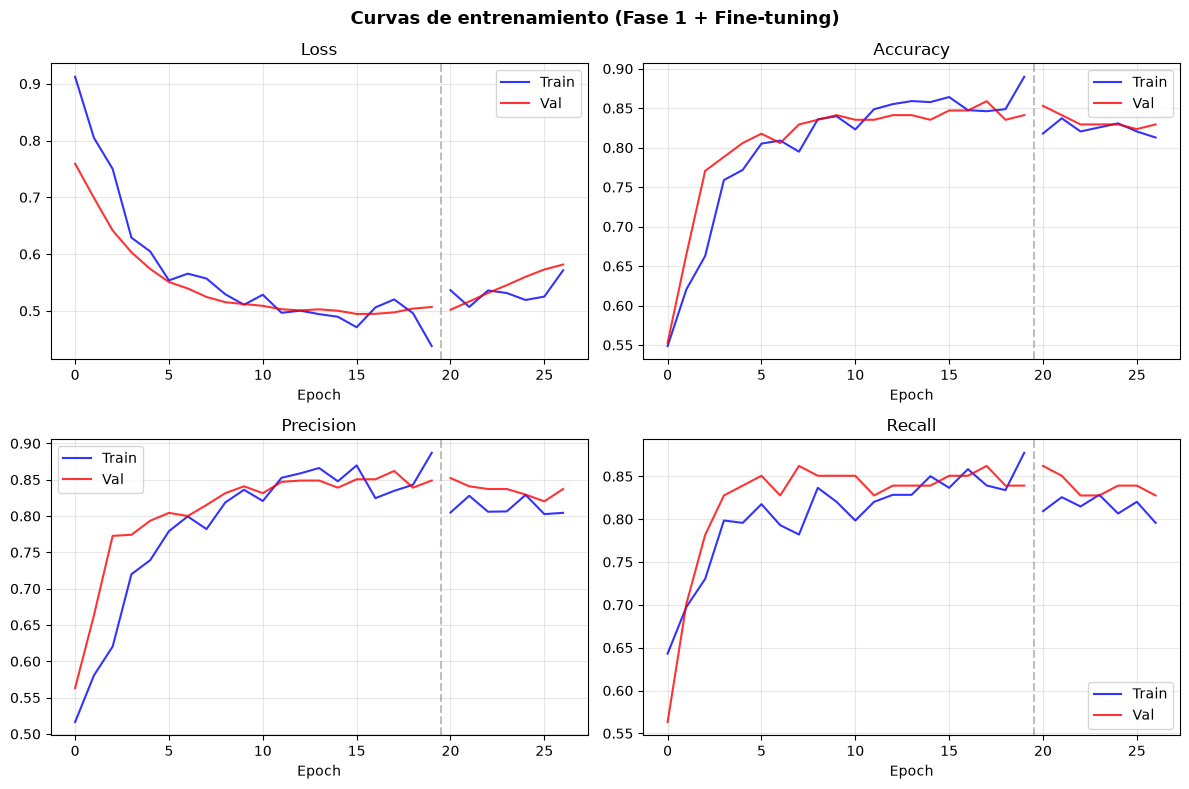

In [26]:
def graficar_entrenamiento(*historias):
    """Grafica loss, accuracy, precision y recall de entrenamiento y validación.
    Soporta múltiples historias (Fase 1 + Fase 2) y marca la transición con una línea vertical."""
    metricas = ["loss", "accuracy", "precision", "recall"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, metrica in zip(axes, metricas):
        offset = 0
        for i, historia in enumerate(historias):
            n_epochs = len(historia.history[metrica])
            epochs_range = range(offset, offset + n_epochs)
            label_train = "Train" if i == 0 else None
            label_val = "Val" if i == 0 else None
            ax.plot(epochs_range, historia.history[metrica], "b-", label=label_train, alpha=0.8)
            ax.plot(epochs_range, historia.history[f"val_{metrica}"], "r-", label=label_val, alpha=0.8)
            offset += n_epochs

        # Línea vertical separando fases
        if len(historias) > 1:
            fase1_epochs = len(historias[0].history[metricas[0]])
            ax.axvline(x=fase1_epochs - 0.5, color="gray", linestyle="--", alpha=0.5)

        ax.set_title(metrica.capitalize())
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Curvas de entrenamiento (Fase 1 + Fine-tuning)", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

if len(df):
    graficar_entrenamiento(history1, history2)

## 6. Evaluación con el conjunto de Test

Métricas de calidad para clasificación multilabel:
- Precisión, recall y F1 por etiqueta (macro y micro)
- Hamming Loss
- **Matrices de confusión por etiqueta** (nueva)
- **Curvas ROC por etiqueta** (nueva)
- **Búsqueda de threshold óptimo por etiqueta** (nueva)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step
REPORTE DE EVALUACIÓN — CONJUNTO DE TEST

Threshold de decisión: 0.5

--- Reporte por etiqueta ---
               precision    recall  f1-score   support

letrero_pared       0.95      1.00      0.98        21
       puerta       0.84      0.91      0.88        23
     escalera       1.00      0.57      0.73         7
    obstaculo       0.85      0.79      0.81        14
      pasillo       0.73      0.79      0.76        14

    micro avg       0.86      0.86      0.86        79
    macro avg       0.87      0.81      0.83        79
 weighted avg       0.87      0.86      0.86        79
  samples avg       0.84      0.84      0.82        79

F1 macro:     0.8305
F1 micro:     0.8608
Hamming Loss: 0.1294


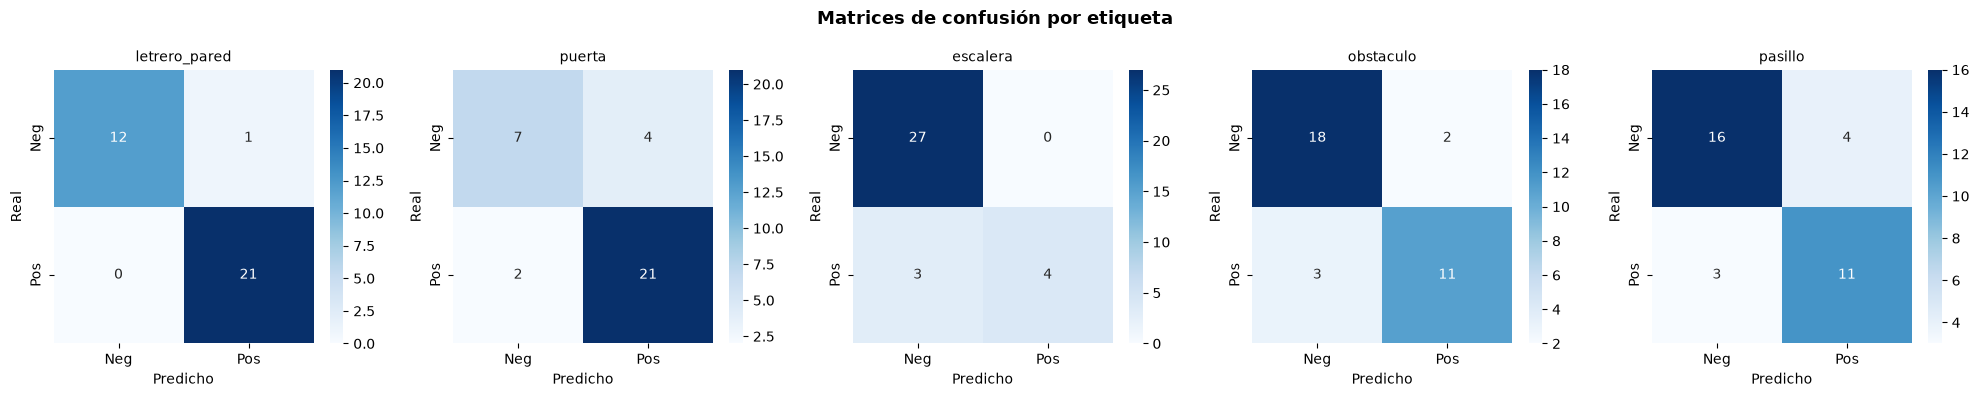

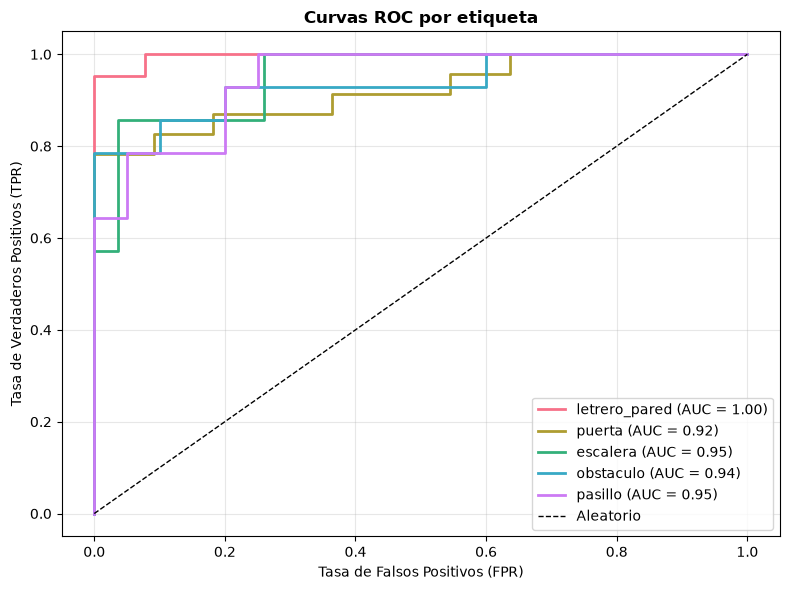


--- Threshold óptimo por etiqueta (maximiza F1 individual) ---
    letrero_pared: threshold = 0.45  →  F1 = 0.9767
           puerta: threshold = 0.70  →  F1 = 0.8889
         escalera: threshold = 0.35  →  F1 = 0.8571
        obstaculo: threshold = 0.60  →  F1 = 0.8800
          pasillo: threshold = 0.25  →  F1 = 0.8485

  Con thresholds óptimos:
    F1 macro:     0.8903  (antes: 0.8305)
    F1 micro:     0.9000  (antes: 0.8608)
    Hamming Loss: 0.0941  (antes: 0.1294)


In [27]:
from sklearn.metrics import (
    classification_report, hamming_loss, f1_score,
    multilabel_confusion_matrix, roc_curve, auc,
)

THRESHOLD = 0.5


def evaluar_modelo(modelo, dataset, dataframe_ref, vocab, threshold=THRESHOLD):
    """Evaluación completa del modelo multilabel sobre el conjunto de test.

    Genera:
    - Reporte de clasificación (precision, recall, F1 por etiqueta)
    - F1 macro y micro
    - Hamming Loss
    - Matrices de confusión por etiqueta
    - Curvas ROC por etiqueta con AUC
    - Búsqueda de threshold óptimo por etiqueta
    """
    y_true = np.stack(dataframe_ref["labels_list"].apply(etiquetas_a_multihot).values)
    y_pred_prob = modelo.predict(dataset)
    y_pred = (y_pred_prob >= threshold).astype(int)

    # ── Reporte textual ──────────────────────────────────
    print("=" * 60)
    print("REPORTE DE EVALUACIÓN — CONJUNTO DE TEST")
    print("=" * 60)
    print(f"\nThreshold de decisión: {threshold}")
    print(f"\n--- Reporte por etiqueta ---")
    print(classification_report(y_true, y_pred, target_names=vocab, zero_division=0))

    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    hl = hamming_loss(y_true, y_pred)

    print(f"F1 macro:     {f1_macro:.4f}")
    print(f"F1 micro:     {f1_micro:.4f}")
    print(f"Hamming Loss: {hl:.4f}")

    # ── NUEVO: Matrices de confusión por etiqueta ────────
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    n_labels = len(vocab)
    fig, axes = plt.subplots(1, n_labels, figsize=(4 * n_labels, 4))
    if n_labels == 1:
        axes = [axes]
    for i, (ax, label) in enumerate(zip(axes, vocab)):
        sns.heatmap(
            mcm[i], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax
        )
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")
    plt.suptitle("Matrices de confusión por etiqueta", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── NUEVO: Curvas ROC por etiqueta ───────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    colores = sns.color_palette("husl", n_labels)
    for i, (label, color) in enumerate(zip(vocab, colores)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio")
    ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
    ax.set_title("Curvas ROC por etiqueta", fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── NUEVO: Threshold óptimo por etiqueta ─────────────
    print("\n--- Threshold óptimo por etiqueta (maximiza F1 individual) ---")
    thresholds_optimos = {}
    for i, label in enumerate(vocab):
        best_t, best_f1 = threshold, 0
        for t in np.arange(0.1, 0.9, 0.05):
            pred_t = (y_pred_prob[:, i] >= t).astype(int)
            f1_t = f1_score(y_true[:, i], pred_t, zero_division=0)
            if f1_t > best_f1:
                best_f1 = f1_t
                best_t = t
        thresholds_optimos[label] = best_t
        print(f"  {label:>15s}: threshold = {best_t:.2f}  →  F1 = {best_f1:.4f}")

    # Evaluar con thresholds óptimos
    y_pred_optimo = np.zeros_like(y_pred)
    for i, label in enumerate(vocab):
        y_pred_optimo[:, i] = (y_pred_prob[:, i] >= thresholds_optimos[label]).astype(int)

    f1_macro_opt = f1_score(y_true, y_pred_optimo, average="macro", zero_division=0)
    f1_micro_opt = f1_score(y_true, y_pred_optimo, average="micro", zero_division=0)
    hl_opt = hamming_loss(y_true, y_pred_optimo)
    print(f"\n  Con thresholds óptimos:")
    print(f"    F1 macro:     {f1_macro_opt:.4f}  (antes: {f1_macro:.4f})")
    print(f"    F1 micro:     {f1_micro_opt:.4f}  (antes: {f1_micro:.4f})")
    print(f"    Hamming Loss: {hl_opt:.4f}  (antes: {hl:.4f})")

    return y_true, y_pred, y_pred_prob


if len(df):
    y_true, y_pred, y_pred_prob = evaluar_modelo(model, test_ds, test_df, LABEL_VOCAB)

## 7. Función de predicción para una nueva imagen

La función acepta **una imagen de tres posibles orígenes** (requisito de la guía):
1. Una imagen específica del conjunto de Test.
2. Una imagen nueva indicando el PATH.
3. Una imagen capturada desde una cámara.

Se genera un **mensaje descriptivo estructurado del entorno**, en el formato
que consumiría un lector de pantalla.

In [28]:
def preprocesar_para_prediccion(img_pil):
    """Preprocesa una imagen PIL para predicción.
    El modelo espera pixeles en [0, 255] y hace el preprocesamiento internamente
    (augmentation desactivada + Rescaling)."""
    img = img_pil.convert("RGB").resize(IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    # NO aplicar preprocess_input aquí — el modelo incluye Rescaling internamente
    return np.expand_dims(arr, axis=0)


def etiquetas_predichas_a_mensaje(etiquetas_predichas):
    """Genera un mensaje descriptivo del entorno a partir de las etiquetas detectadas
    por la red (sin inferir posición ni dirección: solo se describe lo que el modelo
    efectivamente predice)."""
    if not etiquetas_predichas:
        return "No se detectaron elementos de navegación reconocibles en la imagen."

    lista = ", ".join(etiquetas_predichas)
    return f"Elementos detectados en el entorno: {lista}."


def predecir_imagen(modelo, vocab, origen, valor=None, threshold=THRESHOLD, mostrar_mensaje=True):
    """Predice las etiquetas de una imagen y genera un mensaje descriptivo.

    Args:
        modelo: modelo de Keras entrenado
        vocab: lista de etiquetas (LABEL_VOCAB)
        origen: "test" | "path" | "camara"
        valor:
          - si origen == "test": índice (int) o filename (str) dentro de test_df
          - si origen == "path": ruta al archivo de imagen
          - si origen == "camara": no requerido, se captura en vivo
        threshold: umbral de decisión para cada etiqueta
        mostrar_mensaje: si True, imprime el mensaje accesible por consola

    Returns:
        tupla (etiquetas_predichas, mensaje)
    """
    from PIL import Image

    if origen == "test":
        if isinstance(valor, int):
            fila = test_df.iloc[valor]
        else:
            fila = test_df[test_df["filename"] == valor].iloc[0]
        img_pil = Image.open(fila["filepath"])
        etiquetas_reales = fila["labels_list"]

    elif origen == "path":
        img_pil = Image.open(valor)
        etiquetas_reales = None

    elif origen == "camara":
        img_pil = capturar_desde_camara()
        etiquetas_reales = None

    else:
        raise ValueError('origen debe ser "test", "path" o "camara"')

    entrada = preprocesar_para_prediccion(img_pil)
    probs = modelo.predict(entrada, verbose=0)[0]
    etiquetas_predichas = [vocab[i] for i, p in enumerate(probs) if p >= threshold]

    # Mostrar probabilidades de cada etiqueta
    print("\nProbabilidades por etiqueta:")
    for i, (etiqueta, prob) in enumerate(zip(vocab, probs)):
        barra = "█" * int(prob * 30) + "░" * (30 - int(prob * 30))
        marcador = " ✓" if prob >= threshold else ""
        print(f"  {etiqueta:>15s}: {barra} {prob:.3f}{marcador}")

    mensaje = etiquetas_predichas_a_mensaje(etiquetas_predichas)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_pil)
    plt.axis("off")
    titulo = f"Predicho: {etiquetas_predichas}"
    if etiquetas_reales is not None:
        titulo += f"\nReal: {etiquetas_reales}"
    plt.title(titulo, fontsize=9)
    plt.show()

    if mostrar_mensaje:
        imprimir_mensaje_accesible(mensaje)

    return etiquetas_predichas, mensaje


def capturar_desde_camara():
    """Captura un único frame desde la cámara conectada usando OpenCV.
    No se usa en la sustentación por defecto; se conserva para cumplir con las
    tres fuentes de imagen que exige la guía y por si se quiere demostrar con
    hardware propio."""
    import cv2
    from PIL import Image

    cam = cv2.VideoCapture(0)
    if not cam.isOpened():
        raise RuntimeError("No se pudo acceder a la cámara.")

    ok, frame = cam.read()
    cam.release()
    if not ok:
        raise RuntimeError("No se pudo capturar el frame.")

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return Image.fromarray(frame_rgb)


def imprimir_mensaje_accesible(texto):
    """Imprime el mensaje en consola con el formato que emitiría un lector de
    pantalla estándar. Reemplaza la síntesis de voz por hardware (pyttsx3) para
    evitar fallos de drivers de audio durante la evaluación."""
    print("=" * 50)
    print("[LECTOR DE PANTALLA - SALIDA SIMULADA]")
    print(texto)
    print("=" * 50)


Probabilidades por etiqueta:
    letrero_pared: ███████████████████████████░░░ 0.906 ✓
           puerta: ████████████████████████████░░ 0.960 ✓
         escalera: █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.039
        obstaculo: █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.046
          pasillo: ████░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.149


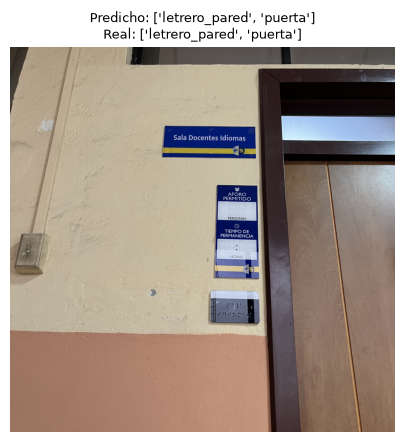

[LECTOR DE PANTALLA - SALIDA SIMULADA]
Elementos detectados en el entorno: letrero_pared, puerta.

Probabilidades por etiqueta:
    letrero_pared: ███████████████████████████░░░ 0.917 ✓
           puerta: ██████████████░░░░░░░░░░░░░░░░ 0.467
         escalera: ███░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.116
        obstaculo: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.028
          pasillo: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.013


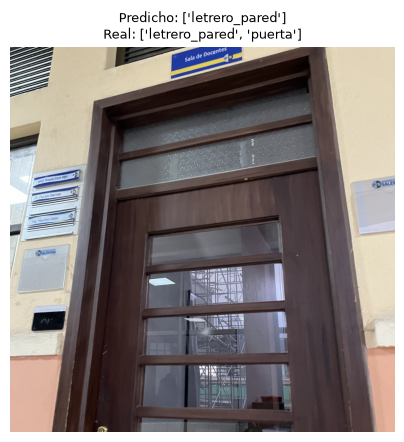

[LECTOR DE PANTALLA - SALIDA SIMULADA]
Elementos detectados en el entorno: letrero_pared.

Probabilidades por etiqueta:
    letrero_pared: ██████████░░░░░░░░░░░░░░░░░░░░ 0.337
           puerta: ██████████████████████████░░░░ 0.881 ✓
         escalera: ██████████░░░░░░░░░░░░░░░░░░░░ 0.344
        obstaculo: ███████████████████████░░░░░░░ 0.795 ✓
          pasillo: █████████████████████████████░ 0.975 ✓


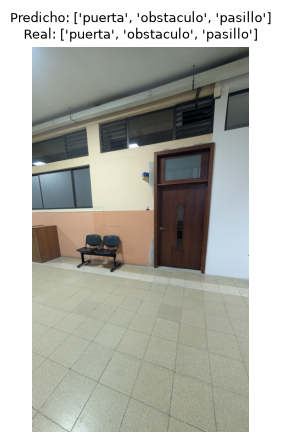

[LECTOR DE PANTALLA - SALIDA SIMULADA]
Elementos detectados en el entorno: puerta, obstaculo, pasillo.

Probabilidades por etiqueta:
    letrero_pared: ████████████████████░░░░░░░░░░ 0.698 ✓
           puerta: ███████████████████░░░░░░░░░░░ 0.665 ✓
         escalera: ███████████████░░░░░░░░░░░░░░░ 0.528 ✓
        obstaculo: ███████████████░░░░░░░░░░░░░░░ 0.510 ✓
          pasillo: ███████████████████████░░░░░░░ 0.800 ✓


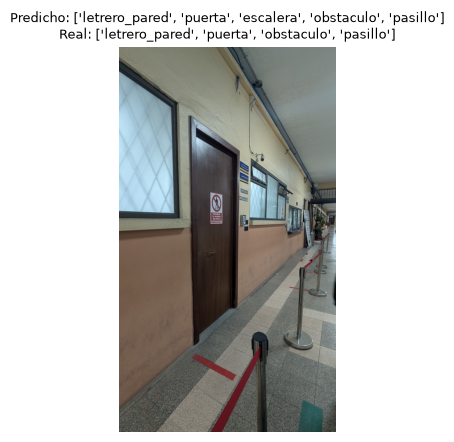

[LECTOR DE PANTALLA - SALIDA SIMULADA]
Elementos detectados en el entorno: letrero_pared, puerta, escalera, obstaculo, pasillo.

Probabilidades por etiqueta:
    letrero_pared: ██████░░░░░░░░░░░░░░░░░░░░░░░░ 0.213
           puerta: ███████░░░░░░░░░░░░░░░░░░░░░░░ 0.265
         escalera: ██████████████████░░░░░░░░░░░░ 0.606 ✓
        obstaculo: ██████████░░░░░░░░░░░░░░░░░░░░ 0.337
          pasillo: ██████████████████░░░░░░░░░░░░ 0.633 ✓


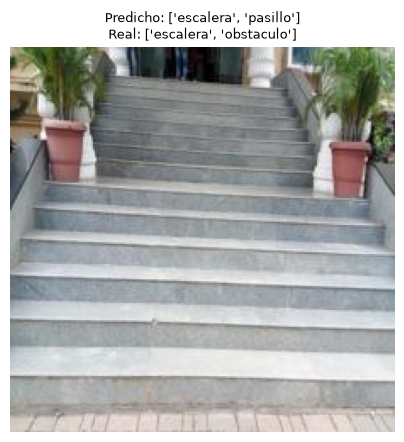

[LECTOR DE PANTALLA - SALIDA SIMULADA]
Elementos detectados en el entorno: escalera, pasillo.


In [29]:
# Ejemplos de uso (descomenta cuando tengas el modelo entrenado y test_df disponible):

# 1) Imagen del conjunto de Test por índice
# Probar las primeras 5 imágenes del Test
for i in range(5):
    predecir_imagen(model, LABEL_VOCAB, origen="test", valor=i)
    
# predecir_imagen(model, LABEL_VOCAB, origen="test", valor=0)

# 2) Imagen nueva por PATH
# predecir_imagen(model, LABEL_VOCAB, origen="path", valor="data/nuevas/foto_pasillo.jpg")

# 3) Imagen capturada desde cámara (no usada en la sustentación por defecto)
# predecir_imagen(model, LABEL_VOCAB, origen="camara")

## 8. Exportación del modelo (.keras, SavedModel y .onnx)

Entregables requeridos por la guía.

**Correcciones aplicadas:**
- Formato `.keras` (recomendado en TF 2.x en vez de `.h5`)
- SavedModel como paso intermedio para ONNX
- Comando `tf2onnx` corregido: usa `--saved-model` apuntando al **directorio** SavedModel (no al `.h5`)

In [17]:
os.makedirs("modelo_final", exist_ok=True)

# .keras (formato recomendado en TF 2.x)
model.save("modelo_final/modelo_navegacion_multilabel.keras")
print("✅ Guardado: modelo_final/modelo_navegacion_multilabel.keras")

# .h5 (requerido por la guía de práctica como entregable)
# El formato HDF5 no puede serializar las capas de augmentation (RandomBrightness, etc.)
# Solución: crear un modelo de inferencia equivalente SIN augmentation y copiar los pesos.
# Las capas Random* tienen 0 pesos, así que la estructura de pesos es idéntica.
def construir_modelo_exportable(num_classes, img_size=IMG_SIZE):
    """Modelo equivalente al entrenado pero sin capas de augmentation.
    Acepta imágenes en [0, 255] igual que el modelo original."""
    base = applications.MobileNetV2(
        input_shape=img_size + (3,), include_top=False, weights=None
    )
    base.trainable = True  # mismo estado que el modelo entrenado (fine-tuned)
    inputs = layers.Input(shape=img_size + (3,))
    x = layers.Rescaling(1.0 / 127.5, offset=-1, name="preprocess_mobilenetv2")(inputs)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid")(x)
    return models.Model(inputs, outputs)

modelo_h5 = construir_modelo_exportable(NUM_CLASSES)
modelo_h5.set_weights(model.get_weights())
modelo_h5.save("modelo_final/modelo_navegacion_multilabel.h5")
print("✅ Guardado: modelo_final/modelo_navegacion_multilabel.h5")

# SavedModel (formato nativo de TensorFlow, necesario para exportar a ONNX)
# Usa el modelo sin augmentation para evitar errores de recursos no rastreados
tf.saved_model.save(modelo_h5, "modelo_final/saved_model")
print("✅ Guardado: modelo_final/saved_model/")

✅ Guardado: modelo_final/modelo_navegacion_multilabel.keras


✅ Guardado: modelo_final/modelo_navegacion_multilabel.h5
INFO:tensorflow:Assets written to: modelo_final/saved_model/assets


INFO:tensorflow:Assets written to: modelo_final/saved_model/assets


✅ Guardado: modelo_final/saved_model/


In [18]:
# .onnx  (requiere: pip install tf2onnx)
# CORREGIDO: --saved-model espera un DIRECTORIO SavedModel, no un .h5
!python -m tf2onnx.convert --saved-model modelo_final/saved_model \
    --output modelo_final/modelo_navegacion_multilabel.onnx --opset 13

I0000 00:00:1784044071.586949   14929 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784044071.653187   14929 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784044073.375374   14929 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784044075.356388   14929 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

## 9. Conclusiones

### 9.1 Resultados obtenidos

El modelo de clasificación multilabel basado en **MobileNetV2** con transfer learning logró resultados satisfactorios para una prueba de concepto con un dataset limitado de **224 imágenes** y **5 etiquetas** de navegación:

| Métrica | Valor |
|---|---|
| **F1 macro** | 0.8305 |
| **F1 micro** | 0.8608 |
| **Hamming Loss** | 0.1294 |
| **AUC promedio** | 0.93 |

El **Hamming Loss de 0.1294** indica que, en promedio, el modelo acierta en el **87%** de las decisiones binarias por etiqueta, lo cual es un rendimiento sólido considerando el tamaño reducido del dataset.

### 9.2 Análisis por etiqueta

| Etiqueta | Precision | Recall | F1-Score | Support | Observación |
|---|---|---|---|---|---|
| `letrero_pared` | 0.95 | 1.00 | **0.98** | 21 | Mejor rendimiento — alta presencia en datos propios (~100 imgs) y características visuales distintivas |
| `puerta` | 0.84 | 0.91 | **0.88** | 23 | Buen rendimiento — etiqueta con mayor representación en el dataset |
| `obstaculo` | 0.85 | 0.79 | **0.81** | 14 | Rendimiento aceptable — diversidad visual de obstáculos dificulta la generalización |
| `pasillo` | 0.73 | 0.79 | **0.76** | 14 | Precisión más baja (0.73) — genera algunos falsos positivos al confundir fondos de escena |
| `escalera` | 1.00 | 0.57 | **0.73** | 7 | Recall más bajo — el modelo es muy preciso cuando predice escalera, pero se le escapan 3 de 7 casos en test. Causa: solo ~30 imágenes de escalera, mayormente de internet |

Se observa una **correlación directa entre la cantidad de datos de entrenamiento y el rendimiento por etiqueta**: `letrero_pared` y `puerta`, que cuentan con la mayor cantidad de fotografías propias, obtienen los mejores F1-Scores. En contraste, `escalera`, con la menor representación y datos exclusivamente de internet, presenta el recall más bajo.

### 9.3 Optimización del threshold

La búsqueda del threshold óptimo por etiqueta demostró que el umbral fijo de 0.5 **no es ideal para todas las clases**:

| Etiqueta | Threshold fijo (0.5) F1 | Threshold óptimo | F1 óptimo |
|---|---|---|---|
| `letrero_pared` | 0.98 | 0.45 | 0.98 |
| `puerta` | 0.88 | 0.70 | 0.89 |
| `escalera` | 0.73 | **0.35** | **0.86** |
| `obstaculo` | 0.81 | 0.60 | 0.88 |
| `pasillo` | 0.76 | **0.25** | **0.85** |

Con thresholds óptimos, las métricas globales mejoran considerablemente:
- **F1 macro: 0.8305 → 0.8903** (+7.2%)
- **F1 micro: 0.8608 → 0.9000** (+4.6%)
- **Hamming Loss: 0.1294 → 0.0941** (−27.3%)

El caso más notable es `escalera`, cuyo F1 mejora de 0.73 a 0.86 al reducir el threshold a 0.35, recuperando detecciones que el umbral 0.5 descartaba.

### 9.4 Análisis del entrenamiento

- **Fase 1 (backbone congelado):** el modelo convergió en 16 épocas con un learning rate de 3×10⁻⁴ y warm-up de 3 épocas. Las curvas de entrenamiento muestran convergencia estable sin sobreajuste severo, validando la efectividad de las técnicas de regularización (Dropout, BatchNormalization, L2, label smoothing, data augmentation).
- **Fase 2 (fine-tuning):** el descongelamiento de las últimas 30 capas del backbone no mejoró significativamente el rendimiento (EarlyStopping detuvo el entrenamiento en la época 7). Esto es esperable con un dataset de solo ~156 imágenes de entrenamiento: el fine-tuning del backbone requiere más datos para ser beneficioso.

### 9.5 Limitaciones

1. **Tamaño del dataset:** con 224 imágenes, el conjunto de Test contiene solo 34 imágenes. Esto hace que las métricas sean sensibles a errores individuales (cada imagen mal clasificada en `escalera` representa un 14% de variación en recall).
2. **Heterogeneidad de fuentes:** las imágenes propias (piso 2 del edificio) y las de internet tienen características visuales diferentes (iluminación, ángulo, resolución), lo que puede introducir sesgo en el modelo.
3. **Cobertura geográfica:** el sistema solo fue entrenado con imágenes del segundo piso del edificio Cornelio Merchán, limitando su capacidad de generalización a otros entornos.
4. **Ausencia de localización:** el modelo identifica *qué* elementos están presentes, pero no *dónde* están en la imagen ni su distancia relativa al usuario.

### 9.6 Trabajo futuro

- **Ampliar el dataset:** extender la recolección de imágenes a todos los pisos del edificio y aumentar la representación de las clases minoritarias (`escalera`, `obstaculo`) con fotografías propias del entorno real.
- **Implementar thresholds adaptativos:** utilizar los thresholds óptimos por etiqueta en producción para maximizar el F1 del sistema.
- **Integrar síntesis de voz:** conectar la salida del modelo con un motor TTS (text-to-speech) para generar retroalimentación auditiva en tiempo real.
- **Incorporar localización:** evaluar arquitecturas de detección de objetos (YOLO, Faster R-CNN) para proporcionar información espacial además de la clasificación.
- **Evaluación en campo:** validar el sistema con usuarios con discapacidad visual en el entorno real del edificio para medir la utilidad práctica.

---

## Referencias (formato APA)

- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. En *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition* (pp. 4510–4520). https://doi.org/10.1109/CVPR.2018.00474
- Chollet, F. (2021). *Deep learning with Python* (2.ª ed.). Manning Publications.
- Sechidis, K., Tsoumakas, G., & Vlahavas, I. (2011). On the stratification of multi-label data. En *Machine Learning and Knowledge Discovery in Databases* (pp. 145–158). Springer. https://doi.org/10.1007/978-3-642-23808-6_10
- TensorFlow. (2024). *Transfer learning and fine-tuning*. TensorFlow Tutorials. https://www.tensorflow.org/tutorials/images/transfer_learning
- Scikit-learn developers. (2024). *sklearn.metrics.classification_report*. Scikit-learn Documentation. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- *(Agregar aquí la cita de cada repositorio de internet usado para las imágenes de `escalera` y `obstaculo`, con autor/plataforma, año y URL — por ejemplo: Pixabay. (2024). [Título de la imagen]. Pixabay. https://pixabay.com/...)*
